In [2]:
import pandas as pd

df = pd.read_csv("agriculture_yield_dataset.csv")

print("Rows and Columns:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 10 Records:")
print(df.head(10))

Rows and Columns:
(1500, 8)

Column Names:
['rainfall_mm', 'temperature_c', 'fertilizer_kg', 'irrigation_hours', 'soil_ph', 'crop_type', 'soil_type', 'yield_ton_per_hectare']

First 10 Records:
   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   
5        831.9           28.0          190.3               2.1      6.1   
6       1023.8           32.0          108.5               6.9      6.2   
7       1142.4           18.4          241.9               4.1      7.3   
8        810.4           36.4          164.8               9.9      6.5   
9       1085.5           29.4           89.3            

In [3]:
print("Data Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumns with Missing Values:")
print(df.columns[df.isnull().sum() > 0].tolist())

Data Types:
rainfall_mm              float64
temperature_c            float64
fertilizer_kg            float64
irrigation_hours         float64
soil_ph                  float64
crop_type                 object
soil_type                 object
yield_ton_per_hectare    float64
dtype: object

Missing Values:
rainfall_mm              0
temperature_c            0
fertilizer_kg            0
irrigation_hours         0
soil_ph                  0
crop_type                0
soil_type                0
yield_ton_per_hectare    0
dtype: int64

Columns with Missing Values:
[]


In [4]:
import numpy as np

print(df.describe())

num_cols = df.select_dtypes(include=np.number)

print("\nHighest Mean Feature:")
print(num_cols.mean().idxmax())

print("\nHighest Std Feature:")
print(num_cols.std().idxmax())

       rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  \
count  1500.000000    1500.000000    1500.000000       1500.000000   
mean    754.054667      27.749467     148.744067          5.403267   
std     255.097216       5.758101      56.990279          2.584329   
min     300.200000      18.000000      50.300000          1.000000   
25%     536.175000      22.600000      98.600000          3.200000   
50%     761.200000      27.700000     146.850000          5.400000   
75%     964.375000      32.600000     196.575000          7.600000   
max    1200.000000      38.000000     249.900000         10.000000   

           soil_ph  yield_ton_per_hectare  
count  1500.000000            1500.000000  
mean      6.759133               5.028793  
std       0.719742               0.968282  
min       5.500000               2.090000  
25%       6.100000               4.337500  
50%       6.800000               5.010000  
75%       7.400000               5.740000  
max       8.00000

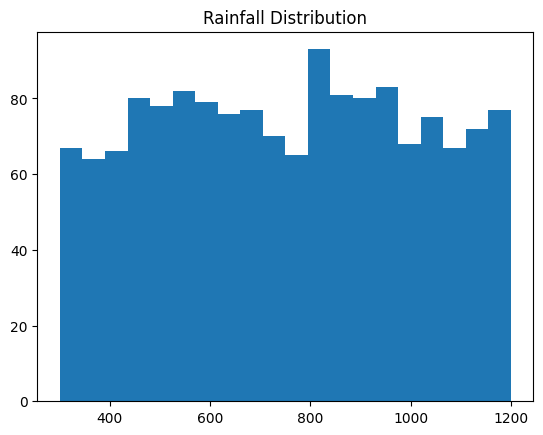

In [5]:
import matplotlib.pyplot as plt

plt.hist(df["rainfall_mm"], bins=20)
plt.title("Rainfall Distribution")
plt.show()

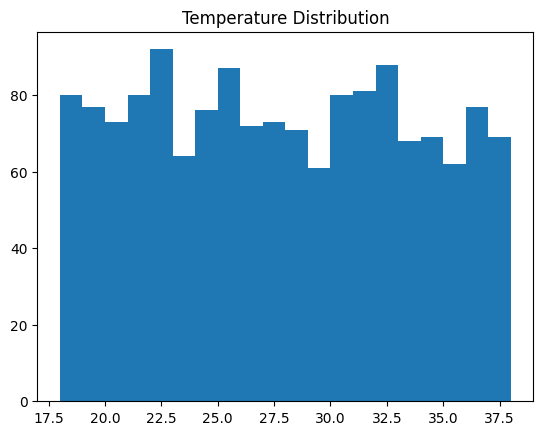

In [6]:
plt.hist(df["temperature_c"], bins=20)
plt.title("Temperature Distribution")
plt.show()

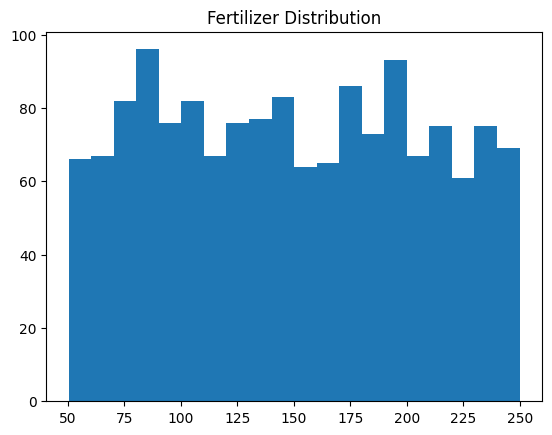

In [7]:
plt.hist(df["fertilizer_kg"], bins=20)
plt.title("Fertilizer Distribution")
plt.show()

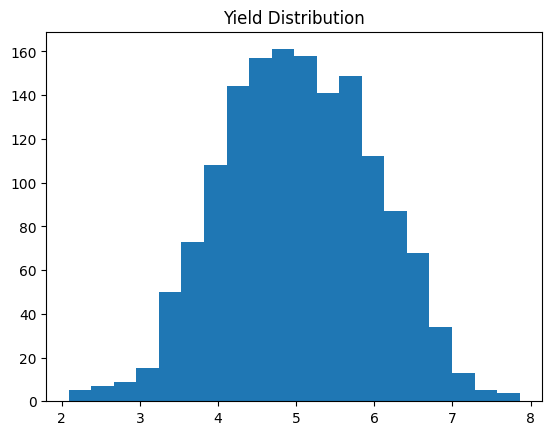

In [8]:
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.show()

In [9]:
print(df["crop_type"].value_counts())

crop_type
Cotton     311
Soybean    306
Wheat      303
Rice       293
Maize      287
Name: count, dtype: int64


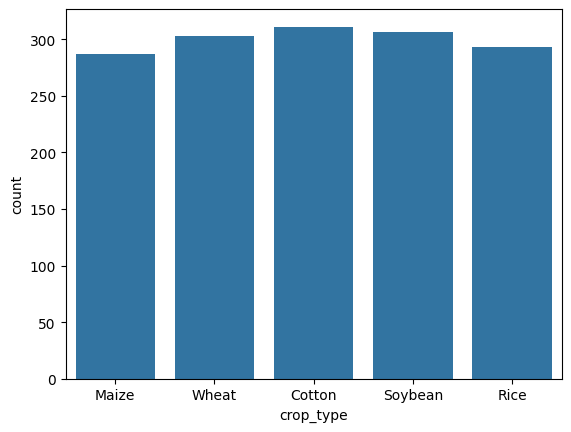

In [10]:
import seaborn as sns

sns.countplot(x="crop_type", data=df)
plt.show()

In [11]:
print("Most Frequent Crop:")
print(df["crop_type"].mode()[0])

Most Frequent Crop:
Cotton


In [12]:
print(df["soil_type"].value_counts())

soil_type
Clay     534
Sandy    492
Loamy    474
Name: count, dtype: int64


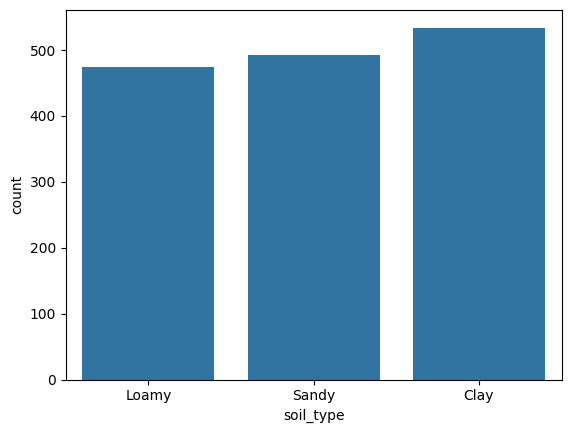

In [13]:
sns.countplot(x="soil_type", data=df)
plt.show()

In [14]:
print("Most Common Soil:")
print(df["soil_type"].mode()[0])

Most Common Soil:
Clay


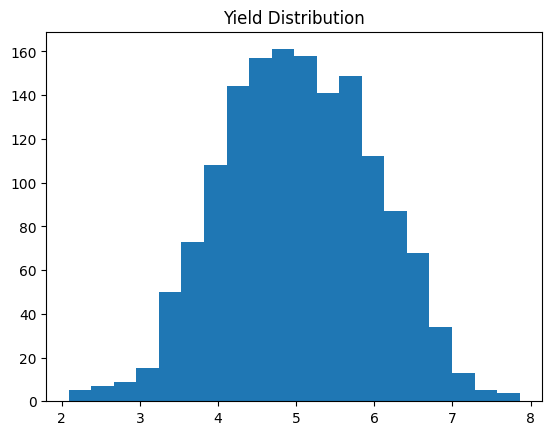

In [15]:
plt.hist(df["yield_ton_per_hectare"], bins=20)
plt.title("Yield Distribution")
plt.show()

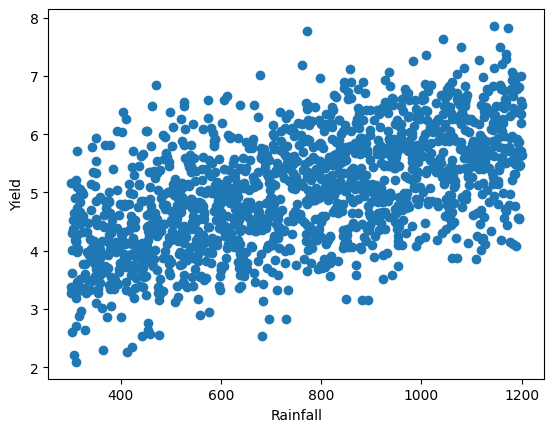

In [16]:
plt.scatter(df["rainfall_mm"],
            df["yield_ton_per_hectare"])

plt.xlabel("Rainfall")
plt.ylabel("Yield")
plt.show()

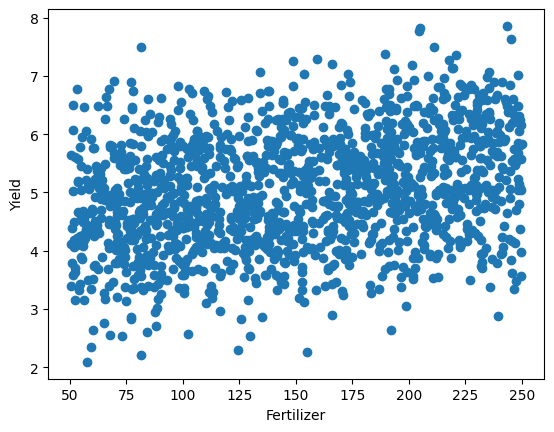

In [17]:
plt.scatter(df["fertilizer_kg"],
            df["yield_ton_per_hectare"])

plt.xlabel("Fertilizer")
plt.ylabel("Yield")
plt.show()

In [18]:
corr = df.corr(numeric_only=True)

print(corr)

                       rainfall_mm  temperature_c  fertilizer_kg  \
rainfall_mm               1.000000       0.026721       0.002558   
temperature_c             0.026721       1.000000       0.037468   
fertilizer_kg             0.002558       0.037468       1.000000   
irrigation_hours          0.010877       0.007114      -0.010497   
soil_ph                   0.006916       0.001513       0.010001   
yield_ton_per_hectare     0.553704      -0.022559       0.278043   

                       irrigation_hours   soil_ph  yield_ton_per_hectare  
rainfall_mm                    0.010877  0.006916               0.553704  
temperature_c                  0.007114  0.001513              -0.022559  
fertilizer_kg                 -0.010497  0.010001               0.278043  
irrigation_hours               1.000000  0.009307               0.542664  
soil_ph                        0.009307  1.000000               0.024412  
yield_ton_per_hectare          0.542664  0.024412               1.000000 

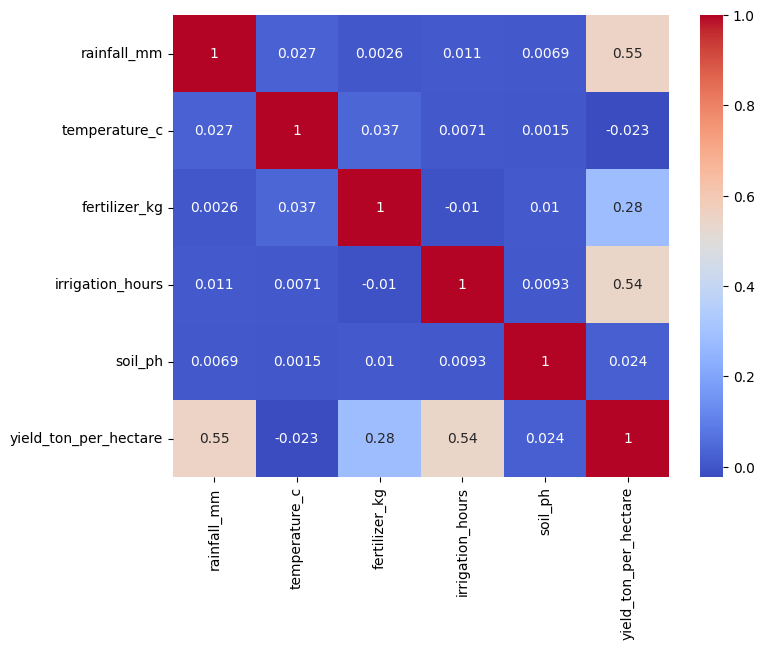

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.show()

In [20]:
corr_with_yield = corr["yield_ton_per_hectare"]\
                    .sort_values(ascending=False)

print(corr_with_yield)

yield_ton_per_hectare    1.000000
rainfall_mm              0.553704
irrigation_hours         0.542664
fertilizer_kg            0.278043
soil_ph                  0.024412
temperature_c           -0.022559
Name: yield_ton_per_hectare, dtype: float64


In [21]:
crop_avg = df.groupby("crop_type")[
    "yield_ton_per_hectare"
].mean()

print(crop_avg)

crop_type
Cotton     4.607299
Maize      4.897143
Rice       5.494744
Soybean    5.173431
Wheat      4.989472
Name: yield_ton_per_hectare, dtype: float64


In [22]:
soil_avg = df.groupby("soil_type")[
    "yield_ton_per_hectare"
].mean()

print(soil_avg)

soil_type
Clay     5.134326
Loamy    5.366519
Sandy    4.588882
Name: yield_ton_per_hectare, dtype: float64


In [23]:
print("Best Crop:")
print(crop_avg.idxmax())

print("Best Soil:")
print(soil_avg.idxmax())

Best Crop:
Rice
Best Soil:
Loamy


In [24]:
print(df.select_dtypes(include="object").columns)

Index(['crop_type', 'soil_type'], dtype='object')


In [25]:
df_encoded = pd.get_dummies(
    df,
    columns=["crop_type","soil_type"],
    drop_first=True
)

print(df_encoded.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   yield_ton_per_hectare  crop_type_Maize  crop_type_Rice  crop_type_Soybean  \
0                   5.92             True           False              False   
1                   6.24             True           False              False   
2                   4.77            False           False              False   
3                   4.04             True           False              False   
4                   5.17            False           False              False   

   crop_type_Wheat  soil_type_Loamy  soil_type_Sandy  
0            

In [26]:
X = df_encoded.drop(
    "yield_ton_per_hectare",
    axis=1
)

y = df_encoded["yield_ton_per_hectare"]

print(X.head())
print(y.head())

   rainfall_mm  temperature_c  fertilizer_kg  irrigation_hours  soil_ph  \
0        588.6           18.6          242.4               6.5      6.5   
1        772.8           34.6          247.2              10.0      6.5   
2        970.9           36.3          168.4               7.3      6.4   
3        611.7           19.0          121.7               3.7      6.0   
4        696.1           29.6          184.6               5.1      6.1   

   crop_type_Maize  crop_type_Rice  crop_type_Soybean  crop_type_Wheat  \
0             True           False              False            False   
1             True           False              False            False   
2            False           False              False             True   
3             True           False              False            False   
4            False           False              False            False   

   soil_type_Loamy  soil_type_Sandy  
0             True            False  
1            False          

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1200, 11)
X_test : (300, 11)
y_train: (1200,)
y_test : (300,)


In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
print(model.intercept_)

1.587132027736121


In [30]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef_df)

              Feature  Coefficient
0         rainfall_mm     0.002035
1       temperature_c    -0.009175
2       fertilizer_kg     0.004978
3    irrigation_hours     0.198327
4             soil_ph     0.004901
5     crop_type_Maize     0.238931
6      crop_type_Rice     0.863993
7   crop_type_Soybean     0.481719
8     crop_type_Wheat     0.348474
9     soil_type_Loamy     0.302974
10    soil_type_Sandy    -0.490933


In [31]:
print(
    coef_df.loc[
        coef_df["Coefficient"].idxmax()
    ]
)

Feature        crop_type_Rice
Coefficient          0.863993
Name: 6, dtype: object
